# 20-Day Cross-Sectional Momentum Strategy

This notebook applies the (reusable) backtesting framework in `quant_tools` to a simple momentum strategy.

The momentum strategy is as follows: at each market open, stocks are ranked by their previous 20-day open-to-open
return. This strategy invests entirely in the stock with the highest momentum score and holds that position until 
the next rebalance.

The notebook evaluates:

- portfolio performance after transaction costs;
- comparison with SPY, NVDA, and an equal-weight portfolio;
- benchmark-relative statistics including beta, alpha, tracking error, and information ratio;
- cross-sectional information coefficients over multiple forward-return horizons;
- momentum-quintile and extreme-rank behaviour;
- an alternative Top-5 momentum portfolio.

The purpose of the analysis is not to present the strategy as a production-ready trading system, 
but to demonstrate a structured workflow for signal construction, portfolio formation, backtesting, 
benchmarking, and signal evaluation.

In [164]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from quant_tools.data_updater import update_data
from quant_tools.backtester import backtest
from quant_tools.performance import benchmark_analysis
from quant_tools.signal_metrics import (
    information_coefficients_by_horizon,
    quantile_forward_returns,
    extreme_rank_forward_returns,
)

In [165]:
#check that quant_tools file is being accessed correctly
import quant_tools.data_updater as du

print(dir(du))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'os', 'pd', 'update_data', 'yf']


In [166]:
#for our data, we use a collection of tickers from a variety of domains
tickers = [
    # Technology
    "AAPL", "MSFT", "NVDA", "AVGO", "ORCL",

    # Communication / internet
    "GOOGL", "META", "NFLX",

    # Consumer
    "AMZN", "TSLA", "HD", "COST", "MCD",

    # Financials
    "JPM", "BAC", "GS", "V", "MA",

    # Healthcare
    "JNJ", "UNH", "LLY", "MRK",

    # Energy
    "XOM", "CVX",

    # Industrials
    "CAT", "GE", "HON",

    # Consumer staples
    "WMT", "PG", "KO"
]

stock_data = {ticker: update_data(ticker) for ticker in tickers}

open_prices = pd.DataFrame({ticker: stock_data[ticker]["Open"] for ticker in tickers})

spy_data = update_data("SPY")
spy_open = spy_data["Open"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [167]:
#in this cell, we set up the portfolio weights based upon momentum ranks
#and winner-takes-all
lookback = 20

momentum = open_prices.pct_change(lookback)

momentum_rank = momentum.rank(axis=1, ascending=False)

target_weights = momentum_rank.eq(1).astype(float)

#no strategy exists until the lookback window is available.
target_weights.loc[momentum.isna().all(axis=1)] = np.nan

#forward open-to-open returns.
returns = open_prices.shift(-1) / open_prices - 1

first_strategy_date = target_weights.dropna().index[0]

#use the same evaluation period throughout.
returns = returns.loc[first_strategy_date:]
target_weights = target_weights.loc[first_strategy_date:]

In [168]:
#run our strategy through the backtest function
results = backtest(
    asset_returns=returns,
    target_weights=target_weights,
    initial_capital=10_000,
    cost_per_side=0.001
)

In [169]:
#we may observe the number of days that trades were made, as well as the total transaction costs incurred
print("Momentum trade days:", results["num_trade_days"])
print("Momentum transaction costs:", results["total_transaction_costs"])

Momentum trade days: 438
Momentum transaction costs: 63846.30040303809


## Passive Benchmark Construction

We would like to compare the performance of our strategy to other, more basic strategies,
such as buying and holding a set of assets for the entire trading period.

The backtester expects portfolio instructions in the form of a target-weight
DataFrame. The momentum strategy naturally produces such weights on each rebalance date, 
whereas a buy-and-hold strategy requires only a single initial allocation.

The helper function (one_time_allocation) below converts a one-time allocation (buy and hold) into the same target-weight format. 
The desired weights are specified on the first date, while all subsequent rows are left as `NaN`, 
indicating that no further rebalancing should occur.

This allows passive portfolios such as 100% NVDA, an equal-weight stock portfolio, 
and 100% SPY to be evaluated using exactly the same backtesting engine and accounting assumptions as the momentum strategy.

In [170]:
def one_time_allocation(returns, allocation):
    target = pd.DataFrame(np.nan, index=returns.index, columns=returns.columns)

    weights = pd.Series(0.0, index=returns.columns)

    for ticker, weight in allocation.items():

        if ticker not in returns.columns:
            raise ValueError(f"{ticker} is not present in returns.")

        weights.loc[ticker] = weight

    target.loc[target.index[0]] = weights

    return target

In [171]:
#set up the buy-and-hold portfolio for NVDA
nvda_weights = one_time_allocation(returns, {"NVDA": 1.0})

#set up the buy-and-hold portfolio for equal weights
n_assets = len(returns.columns)

equal_weight_allocation = {ticker: 1 / n_assets for ticker in returns.columns}

equal_weight_weights = one_time_allocation(returns, equal_weight_allocation)

nvda_results = backtest(
    returns,
    nvda_weights,
    initial_capital=10_000,
    cost_per_side=0.001
)

equal_weight_results = backtest(
    returns,
    equal_weight_weights,
    initial_capital=10_000,
    cost_per_side=0.001
)

In [172]:
#in order to compare the efficacy of our strategy independent of overall market behavior,
#we compare it to the S&P500 buy-and-hold strategy as a proxy
spy_returns = (spy_open.shift(-1) / spy_open - 1).loc[first_strategy_date:]

spy_returns_df = spy_returns.to_frame("SPY")

spy_weights = one_time_allocation(spy_returns_df, {"SPY": 1.0})

spy_results = backtest(
    spy_returns_df,
    spy_weights,
    initial_capital=10_000,
    cost_per_side=0.001
)

In [173]:
#the following helper function grabs and displays some key outputs of the backtest function
def summarize_backtest(result):
    return {
        "Final Value": result["final_value"],
        "CAGR": result["cagr"],
        "Volatility": result["annualized_volatility"],
        "Sharpe": result["sharpe_ratio"],
        "Max Drawdown": result["max_drawdown"],
    }

In [174]:
comparison = pd.DataFrame({
    "Momentum": summarize_backtest(results),
    "Equal Weight": summarize_backtest(equal_weight_results),
    "NVDA": summarize_backtest(nvda_results),
    "SPY": summarize_backtest(spy_results),
}).T

comparison

,Final Value,CAGR,Volatility,Sharpe,Max Drawdown
Momentum,112315.968006,0.443979,0.501974,0.852536,-0.614616
Equal Weight,47617.316631,0.267511,0.234112,1.129948,-0.309551
NVDA,371449.328852,0.731672,0.528487,1.302239,-0.672533
SPY,25624.515765,0.153651,0.192567,0.838610,-0.320800


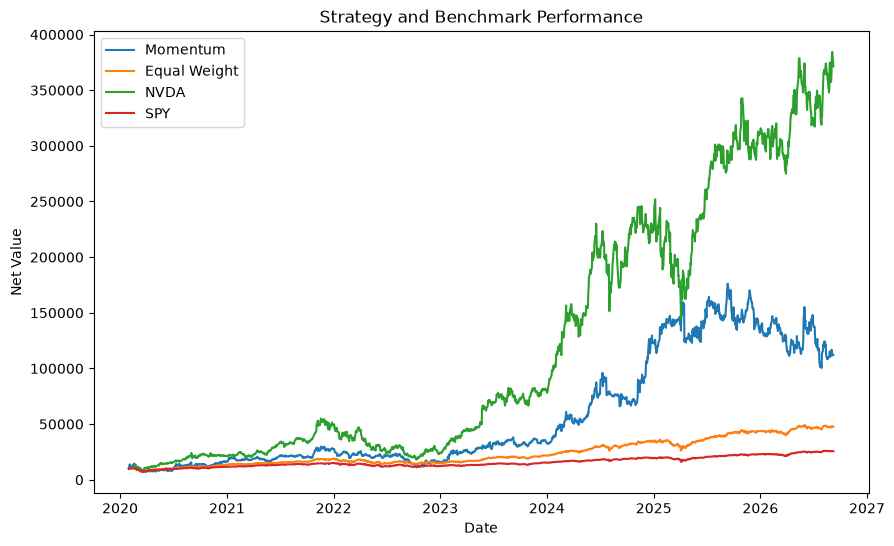

In [175]:
#plot the various strategies for succinct representation of the results
plt.figure(figsize=(10, 6))

plt.plot(results["net_equity_curve"], label="Momentum")

plt.plot(equal_weight_results["net_equity_curve"], label="Equal Weight")

plt.plot(nvda_results["net_equity_curve"], label="NVDA")

plt.plot(spy_results["net_equity_curve"], label="SPY")

plt.title("Strategy and Benchmark Performance")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.legend()
plt.show()

In [176]:
#we use the benchmark_analysis function from the quant_tools file, using SPY as the bencmark data
benchmark_metrics = benchmark_analysis(strategy_returns=results["net_returns"], benchmark_returns=spy_returns)

benchmark_metrics

Correlation          0.414392
Beta                 1.080268
Annualized Alpha     0.253336
Tracking Error       0.457108
Information Ratio    0.582598
dtype: float64

## Benchmark Interpretation

At the time of writing, the strategy shows a moderate positive relationship with SPY, 
with a correlation of approximately 0.41. Its beta is close to 1.08,
suggesting that its overall market sensitivity is only slightly greater than
that of the benchmark.

The estimated annualized alpha is approximately 25.2% under the current zero-risk-free-rate assumption. 
This is relatively large, but should be interpreted cautiously because the analysis is entirely in-sample and the
strategy is tested on a fixed, retrospectively selected stock universe.

The tracking error is approximately 45.7%, which is consistent with the fact that the strategy 
behaves very differently from SPY despite having a beta near one. The information ratio of approximately 0.58 
indicates that the strategy generated positive benchmark-relative returns over the sample, but with a
substantial amount of benchmark-relative volatility.

These results suggest that the strategy's historical performance is not simply 
the result of taking larger exposure to the broad equity market. However, portfolio-level performance 
alone cannot determine whether the underlying momentum signal itself contains predictive information.

The next section therefore examines the signal directly using cross-sectional information coefficients and rank-based return analysis.

## Signal Analysis

The portfolio results are encouraging in absolute terms, but they do not tell us whether the momentum ranking itself contains useful predictive information. The winner-takes-all strategy may perform well because of behaviour concentrated in a small part of the ranking, rather than because higher momentum is generally associated with higher future returns.

To investigate this, we examine the signal directly across several forward-return horizons. We first measure the cross-sectional relationship between momentum ranks and subsequent returns, then look at return behaviour by momentum quintile and at the extreme-ranked stocks.

The aim is to distinguish between broad signal quality and performance that is driven by a narrow subset of the ranking.

In [177]:
#we compute the IC over several return-horizons
horizons = [1, 5, 10, 20]

ic_summary = information_coefficients_by_horizon(
    signal=momentum,
    prices=open_prices,
    horizons=horizons,
)

ic_summary

,Mean IC,IC Std,IC t-stat,Observations
Forward Return Horizon,,,,
1,-0.000088,0.305533,-0.011781,1659.0
5,0.000951,0.291987,0.132468,1655.0
10,-0.007026,0.275221,-1.037015,1650.0
20,-0.002480,0.272929,-0.368019,1640.0


In [178]:
#for each date, we separate our stocks into quantiles based upon momentum scores
#we then take the mean forward returns (over our various horizons) for each quantile
quantile_summary = quantile_forward_returns(
    signal=momentum,
    prices=open_prices,
    horizons=horizons,
)

quantile_summary

,Q1,Q2,Q3,Q4,Q5
Forward Horizon,,,,,
1,0.001053,0.000990,0.000619,0.000925,0.001150
5,0.005671,0.003907,0.003688,0.004319,0.005730
10,0.010919,0.007794,0.008128,0.007955,0.011647
20,0.021321,0.017695,0.015764,0.016290,0.023309


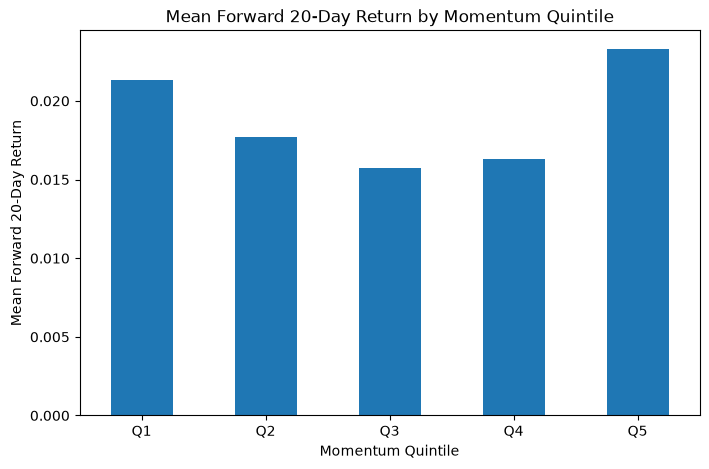

In [179]:
quantile_summary.loc[20].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Mean Forward 20-Day Return by Momentum Quintile"
)
plt.xlabel("Momentum Quintile")
plt.ylabel("Mean Forward 20-Day Return")
plt.xticks(rotation=0)
plt.show()

In [180]:
extreme_summary = extreme_rank_forward_returns(
    signal=momentum,
    prices=open_prices,
    horizons=horizons,
)

extreme_summary

,Top Rank,Rest of Q5,Bottom Rank,Rest of Q1
Forward Horizon,,,,
1,0.002226,0.000935,0.001324,0.000999
5,0.009029,0.005070,0.007521,0.005301
10,0.017034,0.010569,0.011184,0.010866
20,0.028520,0.022267,0.025288,0.020528


### Momentum Extremes and Volatility

Both extreme momentum quintiles exhibit substantially higher realized
volatility than the middle quintiles. This is consistent with the fact that
higher-volatility stocks are more likely to experience extreme cumulative
returns over a fixed lookback period.

Consequently, the strong subsequent returns observed in Q1 and Q5 should
not be interpreted as pure reversal or momentum effects without controlling
for volatility.

In [181]:
daily_returns = open_prices / open_prices.shift(1) - 1

realized_volatility = daily_returns.rolling(20).std(ddof=1) * np.sqrt(252)

In [182]:
volatility_by_quintile = []

for date in momentum.index:
    signal_today = momentum.loc[date]
    volatility_today = realized_volatility.loc[date]

    valid = signal_today.notna() & volatility_today.notna()

    signal_today = signal_today[valid]
    volatility_today = volatility_today[valid]

    if len(signal_today) < 5:
        continue

    signal_rank = signal_today.rank(method="first")

    quintiles = pd.qcut(signal_rank, q=5, labels=[1, 2, 3, 4, 5])

    daily_quintile_volatility = volatility_today.groupby(quintiles, observed=True).mean()

    volatility_by_quintile.append(daily_quintile_volatility)

volatility_by_quintile = pd.DataFrame(volatility_by_quintile)

mean_volatility_by_quintile = (volatility_by_quintile.mean())

mean_volatility_by_quintile.index = ["Q1", "Q2", "Q3", "Q4", "Q5"]

mean_volatility_by_quintile

Q1    0.335690
Q2    0.273242
Q3    0.264242
Q4    0.271677
Q5    0.351070
dtype: float64

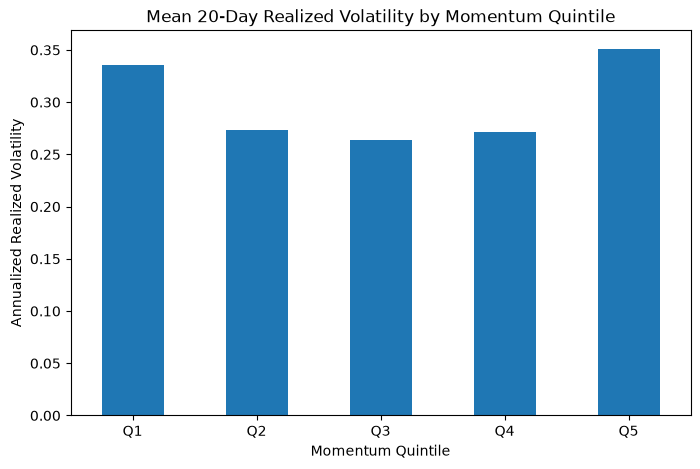

In [183]:
mean_volatility_by_quintile.plot(kind="bar", figsize=(8, 5))

plt.title("Mean 20-Day Realized Volatility by Momentum Quintile")
plt.xlabel("Momentum Quintile")
plt.ylabel("Annualized Realized Volatility")
plt.xticks(rotation=0)
plt.show()

### Portfolio Construction: Rank 1 vs Top 5

The original strategy invests entirely in the stock with the highest
20-day momentum. To test whether diversification improves the use of the
signal, we compare it with a portfolio that equally weights the five
highest-momentum stocks at each rebalance.

In [184]:
top_n = 5

top5_weights = (momentum_rank <= top_n).astype(float)

top5_weights = top5_weights.div(top5_weights.sum(axis=1), axis=0)

top5_weights.loc[momentum.isna().all(axis=1)] = np.nan

top5_weights = top5_weights.loc[returns.index]

In [185]:
top5_results = backtest(
    asset_returns=returns,
    target_weights=top5_weights,
    initial_capital=10_000,
    cost_per_side=0.001
)

In [186]:
portfolio_comparison = pd.DataFrame({
    "Rank 1": summarize_backtest(results),
    "Top 5": summarize_backtest(top5_results),
}).T

portfolio_comparison["Trade Days"] = [
    results["num_trade_days"],
    top5_results["num_trade_days"],
]

portfolio_comparison["Transaction Costs"] = [
    results["total_transaction_costs"],
    top5_results["total_transaction_costs"],
]

portfolio_comparison

,Final Value,CAGR,Volatility,Sharpe,Max Drawdown,Trade Days,Transaction Costs
Rank 1,112315.968006,0.443979,0.501974,0.852536,-0.614616,438,63846.300403
Top 5,32579.589296,0.196508,0.264302,0.688036,-0.409300,1659,19312.985874


### Portfolio Construction: Rank 1 vs Top 5

Diversifying the momentum strategy across the five highest-ranked stocks
substantially reduces volatility and maximum drawdown, but also materially
reduces return. The Top-5 portfolio achieves a lower Sharpe ratio than the
original Rank-1 strategy and also underperforms the passive equal-weight
portfolio on both absolute and risk-adjusted performance.

This result is consistent with the earlier signal analysis. The overall
momentum ranking exhibits little cross-sectional predictive power, while
the single highest-ranked stock displays substantially stronger subsequent
returns than the remainder of the highest momentum quintile. The apparent
predictive content therefore appears concentrated at the extreme upper
tail rather than distributed throughout the ranking.

The Rank-1 strategy nevertheless remains highly concentrated and exhibits
large volatility, drawdowns, and transaction costs. Its strong historical
performance should therefore be interpreted cautiously.

## Overall Interpretation

The 20-day winner-takes-all momentum strategy produces strong historical
returns over the sample, substantially outperforming both SPY and the
equal-weight stock universe in absolute terms. However, this performance
comes with high volatility, deep drawdowns, and substantial transaction
costs.

Cross-sectional information-coefficient analysis shows essentially no
monotonic relationship between 20-day momentum and subsequent returns over
1-, 5-, 10-, or 20-day horizons. Quintile analysis reveals a pronounced
U-shaped relationship instead: both the highest- and lowest-momentum stocks
outperform the middle of the ranking.

Further analysis suggests that the strongest historical performance is
concentrated in the single highest-momentum stock rather than being broadly
distributed across the upper part of the ranking. The highest-ranked stock
outperforms the remainder of the highest-momentum quintile across all tested
forward-return horizons.

A diversified Top-5 momentum portfolio substantially reduces volatility and
drawdown, but also materially reduces returns and produces a lower Sharpe
ratio. It also underperforms the passive equal-weight portfolio on both
absolute and risk-adjusted performance.

The results therefore do not support a general monotonic momentum effect in
this universe. Instead, they suggest that the strong backtest performance is
associated with a much narrower extreme-rank effect. This effect warrants
cautious interpretation because the highest- and lowest-momentum stocks also
exhibit greater realized volatility.

## Limitations

This analysis is intended primarily as a demonstration of a reusable
quantitative research and backtesting framework rather than as evidence of a
production-ready trading strategy.

Several important limitations remain:

- The stock universe consists of a fixed set of currently prominent US
  equities. This introduces survivorship and selection bias because the
  universe is not reconstructed historically.
- The analysis is entirely in-sample. No separate training, validation, or
  out-of-sample period is used.
- Signals and trades are assumed to be implemented approximately at the
  market open. The model does not simulate bid-ask spreads, slippage,
  latency, market impact, or detailed execution mechanics.
- Transaction costs are represented by a fixed proportional cost per dollar
  traded.
- The winner-takes-all strategy is highly concentrated and therefore exposes
  the portfolio to substantial idiosyncratic risk.
- Multi-day forward returns overlap, so observations used in longer-horizon
  signal analysis are not statistically independent.
- The analysis does not control for volatility, sector exposure, market beta,
  or other risk factors when assessing the apparent extreme-rank effect.
- The relatively small cross-sectional universe limits the precision of the
  signal diagnostics.

These limitations mean that the reported historical performance should not
be interpreted as evidence that the strategy would achieve similar returns
in live trading.